In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../data/online_retail.csv")

In [3]:
df.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  Custo

In [4]:
df.shape

(541909, 8)

In [5]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  Cus

In [6]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  C

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
df = df.dropna(subset=["CustomerID"])

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [13]:
df = df[df["Quantity"] > 0]

In [14]:
df = df[df["UnitPrice"] > 0]

In [15]:
df = df.drop_duplicates()

In [16]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)

In [19]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

In [20]:
df.info

<bound method DataFrame.info of         InvoiceNo StockCode                          Description  Quantity  \
0          536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1          536365     71053                  WHITE METAL LANTERN         6   
2          536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3          536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4          536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...           ...       ...                                  ...       ...   
392687     581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
392688     581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
392689     581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
392690     581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
392691     581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  Un

In [21]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

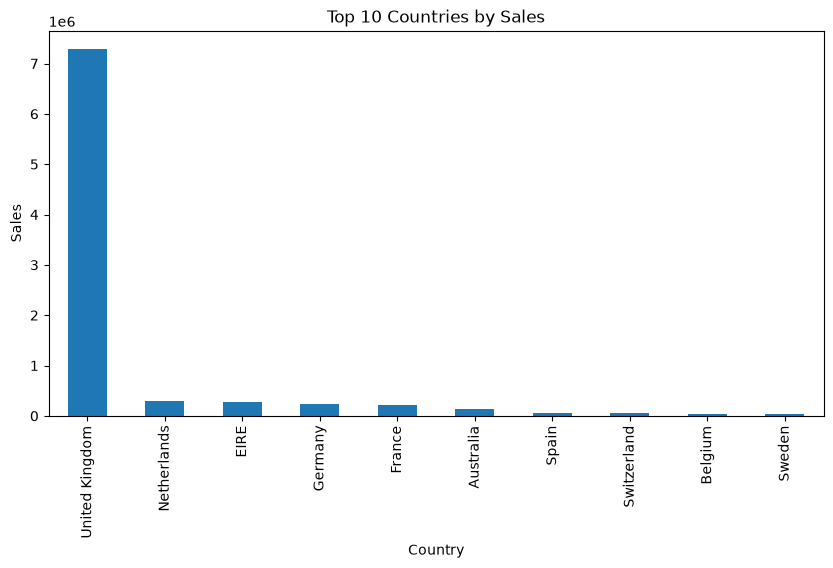

In [22]:
country_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.show()

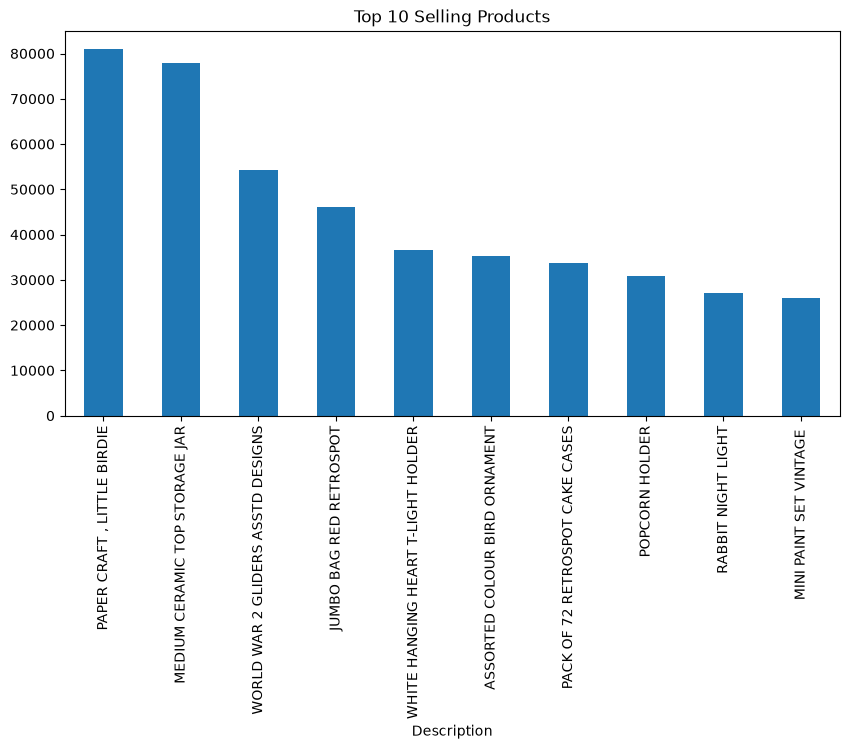

In [23]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_products.head(10)
top_products.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Products")

plt.show()

In [27]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales


Month
2022-12     570422.730
2023-01     568101.310
2023-02     446084.920
2023-03     594081.760
2023-04     468374.331
2023-05     677355.150
2023-06     660046.050
2023-07     598962.901
2023-08     644051.040
2023-09     950690.202
2023-10    1035642.450
2023-11    1156205.610
2023-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

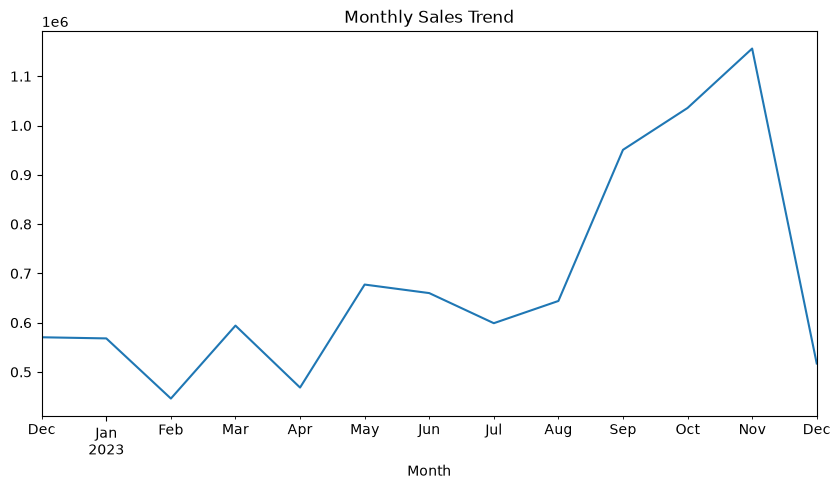

In [28]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")

plt.show()

In [29]:
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)

top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [30]:
#Finding latest date in the dataset
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2023-12-10 12:50:00')

In [31]:
#Making RFM Table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

In [32]:
#Changing column names for better understanding
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [33]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [34]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [35]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [36]:
rfm.to_csv("../data/rfm_data.csv")

In [37]:
rfm = pd.read_csv("../data/rfm_data.csv")

In [38]:
rfm = rfm.drop("CustomerID", axis=1)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [40]:
from sklearn.cluster import KMeans

inertia = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

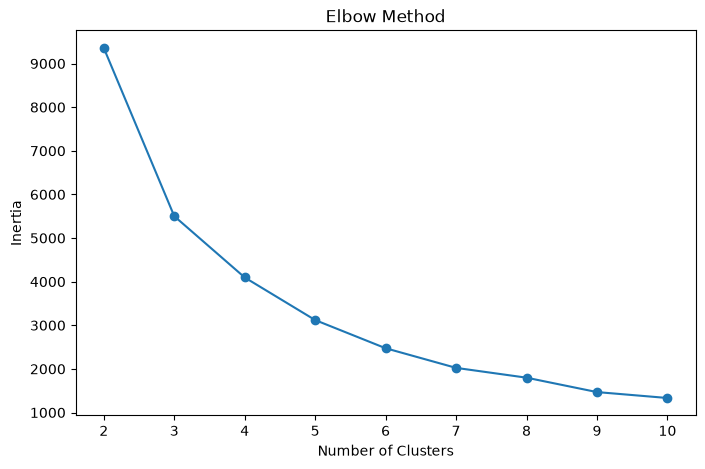

In [41]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [43]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
0,326,1,77183.60,3
1,2,7,4310.00,0
2,75,4,1797.24,0
3,19,1,1757.55,0
4,310,1,334.40,1


In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])

print(score)

0.6162275299061803


In [46]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


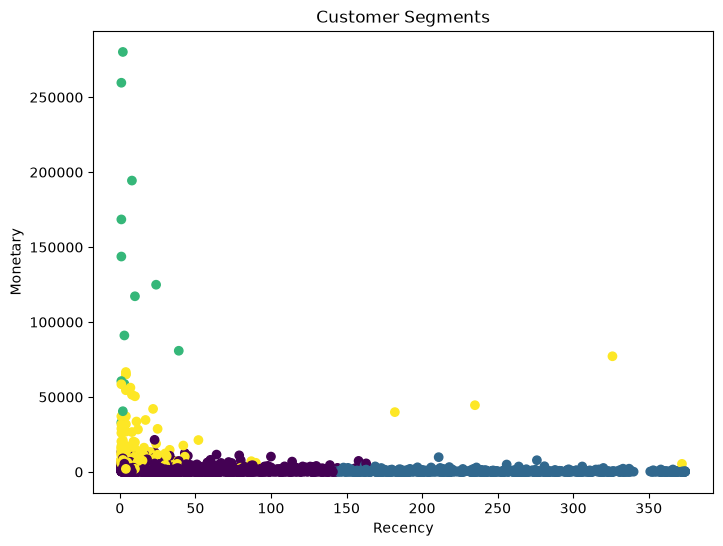

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])

plt.xlabel("Recency")

plt.ylabel("Monetary")

plt.title("Customer Segments")

plt.show()

In [48]:
import joblib

joblib.dump(kmeans,"../models/kmeans_model.pkl")

joblib.dump(scaler,"../models/scaler.pkl")

['../models/scaler.pkl']

In [49]:
#Recommendation System
#pivot_table 
customer_product = df.pivot_table(index="CustomerID", 
                                     columns="Description", 
                                     values="Quantity", 
                                     fill_value=0)

In [50]:
customer_product.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Month'],
      dtype='str')


In [52]:
#Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(customer_product.T)

In [53]:
similarity_df = pd.DataFrame(
    similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

In [54]:
def recommend(product):

    similar = similarity_df[product].sort_values(ascending=False)

    return similar.iloc[1:6]

In [55]:
recommend("WHITE HANGING HEART T-LIGHT HOLDER")

Description
GIN + TONIC DIET METAL SIGN           0.935865
TEA TIME TEA TOWELS                   0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR    0.914906
DOORMAT FAIRY CAKE                    0.888526
RED HANGING HEART T-LIGHT HOLDER      0.258615
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [56]:
import joblib

joblib.dump(similarity_df, "../models/similarity_df.pkl")

print("Similarity file saved successfully!")

Similarity file saved successfully!


In [58]:
print(similarity_df.index[:20])

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' 50'S CHRISTMAS GIFT BAG LARGE',
       ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK',
       ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY',
       ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE',
       ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET',
       ' TOADSTOOL BEDSIDE LIGHT ', ' TRELLIS COAT RACK',
       '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS',
       '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD',
       '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS',
       '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND'],
      dtype='str', name='Description')
